Credit Risk Assessment (Credit Card Default)

Goal: build a model that predicts whether a customer will default on their credit card (`credit_card_default`).

This notebook:
- loads `train.csv` / `test.csv`
- performs quick EDA
- builds a robust preprocessing + modeling pipeline
- evaluates on a validation split (ROC-AUC, PR-AUC, confusion matrix)
- generates `submission_predictions.csv` for the test set

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_DIR = Path(".")
TRAIN_PATH = PROJECT_DIR / "train.csv"
TEST_PATH = PROJECT_DIR / "test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("train:", train.shape)
print("test:", test.shape)
train.head()

train: (45528, 19)
test: (11383, 18)


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [2]:
TARGET = "credit_card_default"
ID_COL = "customer_id"

assert TARGET in train.columns
assert TARGET not in test.columns

# Basic checks
print(train[TARGET].value_counts(dropna=False))
print("Positive rate:", train[TARGET].mean())

missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(12)

credit_card_default
0    41831
1     3697
Name: count, dtype: int64
Positive rate: 0.08120277631347741


no_of_children          1.700053
owns_car                1.201458
no_of_days_employed     1.016957
yearly_debt_payments    0.208663
migrant_worker          0.191091
total_family_members    0.182305
credit_score            0.017572
age                     0.000000
name                    0.000000
customer_id             0.000000
owns_house              0.000000
occupation_type         0.000000
dtype: float64

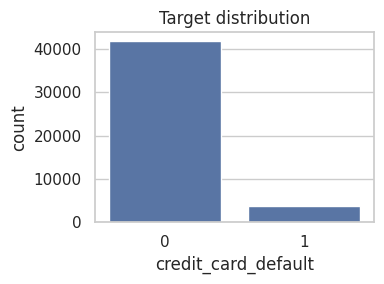

,count,mean,std,min,25%,50%,75%,max
age,45528.0,38.993411,9.543990,23.00,31.000,39.000,47.0000,5.500000e+01
net_yearly_income,45528.0,200655.622249,669074.034607,27170.61,126345.835,171714.910,240603.7600,1.407590e+08
no_of_days_employed,45065.0,67609.289293,139323.524434,2.00,936.000,2224.000,5817.0000,3.652520e+05
yearly_debt_payments,45433.0,31796.965311,17269.727234,2237.47,19231.140,29081.650,40561.1500,3.281129e+05
credit_limit,45528.0,43548.416028,148784.686878,4003.14,23973.805,35688.045,53435.7625,3.112997e+07
credit_limit_used(%),45528.0,52.235020,29.376910,0.00,27.000,54.000,78.0000,9.900000e+01
credit_score,45520.0,782.791257,100.619746,500.00,704.000,786.000,867.0000,9.490000e+02
prev_defaults,45528.0,0.060710,0.264629,0.00,0.000,0.000,0.0000,2.000000e+00
default_in_last_6months,45528.0,0.050540,0.219059,0.00,0.000,0.000,0.0000,1.000000e+00


In [3]:
# EDA: target distribution
plt.figure(figsize=(4, 3))
sns.countplot(x=TARGET, data=train)
plt.title("Target distribution")
plt.tight_layout()
plt.show()

# Numeric feature distributions (a few key fields)
num_cols = [
    "age",
    "net_yearly_income",
    "no_of_days_employed",
    "yearly_debt_payments",
    "credit_limit",
    "credit_limit_used(%)",
    "credit_score",
    "prev_defaults",
    "default_in_last_6months",
]
num_cols = [c for c in num_cols if c in train.columns]

train[num_cols].describe().T

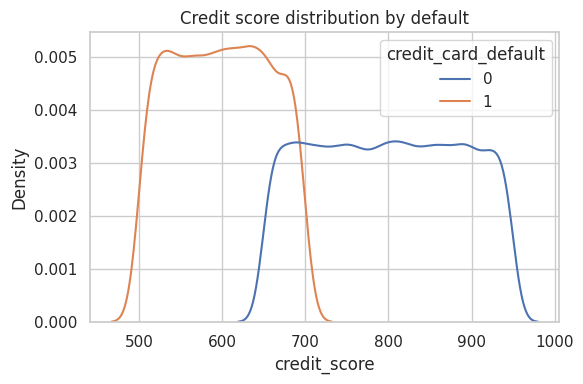

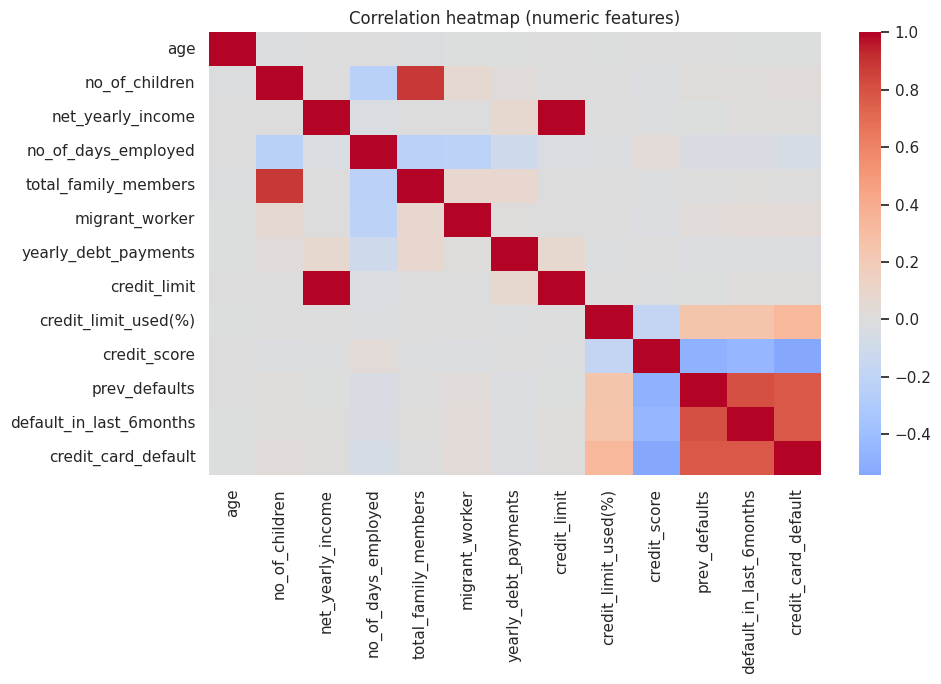

In [4]:
# Quick relationships: credit score vs default
if "credit_score" in train.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=train, x="credit_score", hue=TARGET, common_norm=False)
    plt.title("Credit score distribution by default")
    plt.tight_layout()
    plt.show()

# Correlation heatmap (numeric)
num_train = train.select_dtypes(include="number")
plt.figure(figsize=(10, 7))
sns.heatmap(num_train.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

ROC-AUC: 0.9936678552073169
PR-AUC: 0.9476486918277887

Classification report (threshold=0.5):

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      8367
           1       0.65      0.96      0.77       739

    accuracy                           0.95      9106
   macro avg       0.82      0.96      0.87      9106
weighted avg       0.97      0.95      0.96      9106



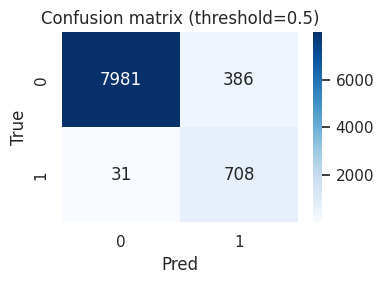

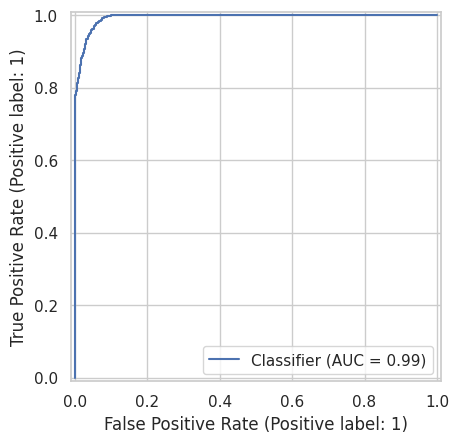

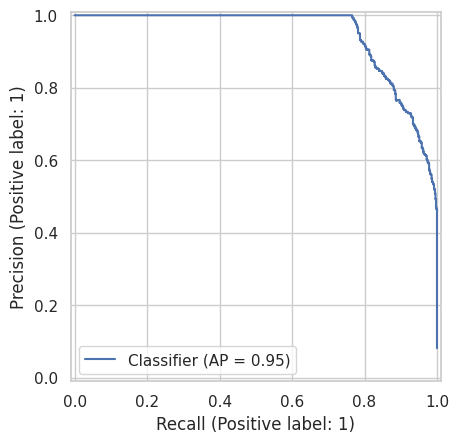

In [5]:
# Modeling

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = train.drop(columns=[TARGET])
y = train[TARGET].astype(int)

# drop obvious leakage/ID-like columns
drop_cols = [c for c in [ID_COL, "name"] if c in X.columns]
X = X.drop(columns=drop_cols)
X_test_final = test.drop(columns=drop_cols)

categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_cols,
        ),
    ],
    remainder="drop",
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "clf",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                n_jobs=None,
            ),
        ),
    ]
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

val_proba = model.predict_proba(X_val)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_val, val_proba))
print("PR-AUC:", average_precision_score(y_val, val_proba))
print("\nClassification report (threshold=0.5):\n")
print(classification_report(y_val, val_pred))

cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix (threshold=0.5)")
plt.xlabel("Pred")
plt.ylabel("True")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_val, val_proba)
plt.show()
PrecisionRecallDisplay.from_predictions(y_val, val_proba)
plt.show()

In [6]:
# Feature impact (Logistic Regression coefficients)

import numpy as np

feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_.ravel()

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

coef_df.head(20)

,feature,coef,abs_coef
9,num__credit_score,-5.516323,5.516323
8,num__credit_limit_used(%),2.732316,2.732316
12,cat__gender_F,-1.524338,1.524338
16,cat__owns_car_Y,-1.489849,1.489849
18,cat__owns_house_Y,-1.387223,1.387223
17,cat__owns_house_N,-1.247181,1.247181
11,num__default_in_last_6months,1.198500,1.198500
31,cat__occupation_type_Private service staff,-1.180387,1.180387
10,num__prev_defaults,1.171293,1.171293
15,cat__owns_car_N,-1.144554,1.144554


In [7]:
# Train on full training data, generate predictions for test set

model.fit(X, y)

test_proba = model.predict_proba(X_test_final)[:, 1]

pred_path = PROJECT_DIR / "submission_predictions.csv"

out = pd.DataFrame({
    ID_COL: test[ID_COL] if ID_COL in test.columns else np.arange(len(test_proba)),
    "credit_card_default_probability": test_proba,
    "credit_card_default_pred_0_5": (test_proba >= 0.5).astype(int),
})

out.to_csv(pred_path, index=False)
print("Wrote:", pred_path)
out.head()

Wrote: submission_predictions.csv


,customer_id,credit_card_default_probability,credit_card_default_pred_0_5
0,CST_142525,0.000003,0
1,CST_129215,0.000530,0
2,CST_138443,1.000000,1
3,CST_123812,0.000002,0
4,CST_144450,1.000000,1
